In [1]:
from sklearn.datasets import fetch_openml
import numpy as np

In [2]:
mnist = fetch_openml('mnist_784', version = 1)
mnist.keys()

dict_keys(['data', 'target', 'frame', 'categories', 'feature_names', 'target_names', 'DESCR', 'details', 'url'])

In [3]:
X, y = mnist["data"], mnist["target"]
X.shape

(70000, 784)

In [4]:
y.shape

(70000,)

In [6]:
'''
There are 70,000 images, and each image has 784 features. This is because each image is 28 x 28 pixels, and
each features simply represents one pixel's intensity, from 0 (white) to  255 (black). 
'''

"\nThere are 70,000 images, and each image has 784 features. This is because each image is 28 x 28 pixels, and\neach features simply represents one pixel's intensity, from 0 (white) to  255 (black). \n"

In [7]:
import matplotlib as mpl
import matplotlib.pyplot as plt

In [8]:
some_digit = X.iloc[0].to_numpy()
some_digit_image = some_digit.reshape(28,28)

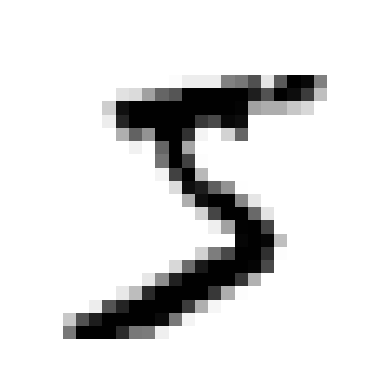

In [9]:
plt.imshow(some_digit_image, cmap="binary")
plt.axis("off")
plt.show()

In [10]:
y[0]

'5'

In [11]:
y = y.astype(np.uint8)

In [12]:
'''
split the training set into 60,000 images and a test set (the lat 10,000 images)
'''

'\nsplit the training set into 60,000 images and a test set (the lat 10,000 images)\n'

In [13]:
X_train, X_test, y_train, y_test = X[:60000], X[60000:], y[:60000], y[60000:]

In [14]:
'''
create the target vectors for this classification task
'''
y_train_5 = (y_train == 5) # True for all 5s, False for all other digits
y_test_5 = (y_test == 5)

In [15]:
'''
Stochastic Gradient Descent(SGD) - has an advantage of being capabl of handling very large datasets efficently.
'''
from sklearn.linear_model import SGDClassifier

In [16]:
sgd_clf = SGDClassifier(random_state=42)
sgd_clf.fit(X_train, y_train_5)

,loss,'hinge'
,penalty,'l2'
,alpha,0.0001
,l1_ratio,0.15
,fit_intercept,True
,max_iter,1000
,tol,0.001
,shuffle,True
,verbose,0
,epsilon,0.1
,n_jobs,None


In [17]:
sgd_clf.predict([some_digit])

/Users/antonioalvarezmaciel/miniconda3/envs/nlp_env/lib/python3.12/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but SGDClassifier was fitted with feature names
  warnings.warn(


array([ True])

In [18]:
'''
Measuring Accuracy using Cross-Validation - how to implement Cross-Validation
'''
from sklearn.model_selection import StratifiedKFold
from sklearn.base import clone


In [19]:
skfolds = StratifiedKFold(n_splits=3, shuffle= True, random_state=42)

for train_index, test_index in skfolds.split(X_train, y_train_5):
    clone_clf = clone(sgd_clf)
    X_train_folds = X_train.iloc[train_index]
    y_train_folds = y_train_5.iloc[train_index]
    X_test_fold = X_train.iloc[test_index]
    y_test_fold = y_train_5.iloc[test_index]

    clone_clf.fit(X_train_folds, y_train_folds)
    y_pred = clone_clf.predict(X_test_fold)
    n_correct = sum(y_pred == y_test_fold)
    print(n_correct / len(y_pred))

0.9669
0.91625
0.96785


In [20]:
from sklearn.model_selection import cross_val_score

In [21]:
cross_val_score(sgd_clf, X_train, y_train_5, cv=3, scoring="accuracy")

array([0.95035, 0.96035, 0.9604 ])

In [22]:
from sklearn.base import BaseEstimator

In [23]:
class Never5Classifier(BaseEstimator):
    def fit(self, X, y=None):
        return self
    def predict(self, X):
        return np.zeros((len(X), 1), dtype=bool)

In [24]:
never_5_clf = Never5Classifier()
cross_val_score(never_5_clf, X_train, y_train_5, cv = 3, scoring="accuracy")

array([0.91125, 0.90855, 0.90915])

In [26]:
from sklearn.datasets import fetch_openml
from sklearn.linear_model import SGDClassifier
from sklearn.metrics import confusion_matrix
from sklearn.model_selection import cross_val_predict
import numpy as np

In [27]:
mnist = fetch_openml("mnist_784", version=1, as_frame=False)
X, y = mnist.data, mnist.target

In [28]:
y = y.astype(np.uint8)

In [29]:
X_train, X_test = X[:60000], X[60000:]
y_train, y_test = y[:60000], y[60000:]

In [30]:
y_train_5 = (y_train == 5)

In [31]:
print("unique y_train_5:", np.unique(y_train_5, return_counts=True))


unique y_train_5: (array([False,  True]), array([54579,  5421]))


In [32]:
sgd_clf = SGDClassifier(random_state=42)

In [33]:
'''
K-fold cross validation, but instead of returning the evaluation scores, 
it returns the predictions made on each test fold
'''

y_train_pred = cross_val_predict(sgd_clf, X_train, y_train_5, cv=3)
conf_mx = confusion_matrix(y_train_5, y_train_pred)
print(conf_mx)

[[53892   687]
 [ 1891  3530]]


In [34]:
y_train_perfect_predictions = y_train_5

In [35]:
confusion_matrix(y_train_5, y_train_perfect_predictions)

array([[54579,     0],
       [    0,  5421]])

In [36]:
from sklearn.metrics import precision_score, recall_score

In [37]:
precision_score(y_train_5, y_train_pred)

0.8370879772350012

In [38]:
recall_score(y_train_5, y_train_pred)

0.6511713705958311

In [39]:
'''
Often convenient to combine precision and reall into a single metric called the F1 score - to compute
the F score, simply call the f1_score() func
'''
from sklearn.metrics import f1_score


In [40]:
f1 = f1_score(y_train_5, y_train_pred)
print(f1)

0.7325171197343847


In [41]:
sgd_clf.fit(X_train, y_train_5)

,loss,'hinge'
,penalty,'l2'
,alpha,0.0001
,l1_ratio,0.15
,fit_intercept,True
,max_iter,1000
,tol,0.001
,shuffle,True
,verbose,0
,epsilon,0.1
,n_jobs,None


In [42]:
some_digit = X[0]

In [43]:
y_scores = sgd_clf.decision_function([some_digit])
print("decision socre:", y_scores)

decision socre: [2164.22030239]


In [45]:
threshold = 8000
y_some_digit_pred = (y_scores > threshold)
y_some_digit_pred

array([False])

In [46]:
y_scores = cross_val_predict(sgd_clf, X_train, y_train_5, cv = 3, 
                             method="decision_function")

In [47]:
from sklearn.metrics import precision_recall_curve

In [48]:
precisions, recalls, thresholds = precision_recall_curve(y_train_5, y_scores)

In [49]:
def plot_precision_recall_vs_threshold(precisions, recalls, thresholds):
    plt.plot(thresholds, precisions[:-1], "b--", label="Precision")
    plt.plot(thresholds, recalls[:-1], "g-", label="Recall")


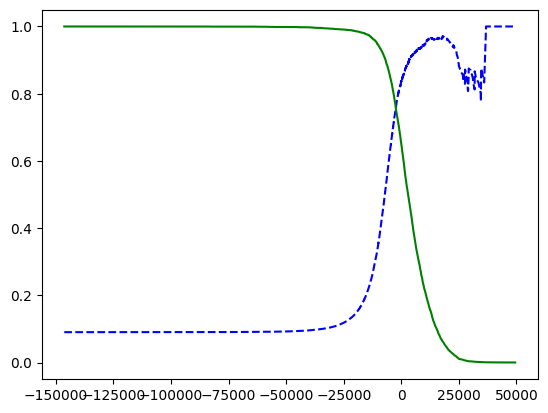

In [50]:
plot_precision_recall_vs_threshold(precisions, recalls, thresholds)
plt.show()

In [51]:
threshold_90_precision = thresholds[np.argmax(precisions >= 90)]

In [52]:
y_train_pred_90 = (y_scores >= threshold_90_precision)

In [53]:
precision_score(y_train_5, y_train_pred_90)

0.09035

In [54]:
recall_score(y_train_5, y_train_pred_90)

1.0

In [55]:
'''
ROC curve plots the true positive rate(another name for recall) against the false positive rate(FPR). The FPR is the ratio of negative instances that are incorrectly classified as positive.
'''
from sklearn.metrics import roc_curve

In [56]:
fpr, tpr, thresholds = roc_curve(y_train_5, y_scores)

In [57]:
def plot_roc_curve(fpr, tpr, label=None):
    plt.plot(fpr, tpr, linewidth=2, label=label)
    plt.plot([0,1], [0,1], 'k--')
    [...]

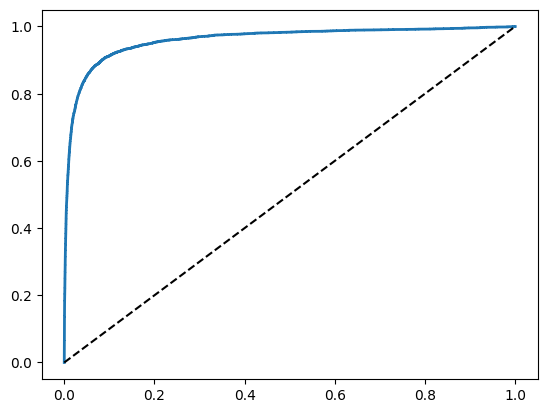

In [58]:
plot_roc_curve(fpr, tpr)
plt.show()

In [59]:
from sklearn.metrics import roc_auc_score

In [60]:
roc_auc_score(y_train_5, y_scores)

0.9604938554008616

In [61]:
from sklearn.ensemble import RandomForestClassifier

In [62]:
forest_clf = RandomForestClassifier(random_state=42)

In [63]:
y_probas_forest = cross_val_predict(forest_clf, X_train, y_train_5, cv=3,
                                    method="predict_proba")

In [64]:
y_scores_forest = y_probas_forest[:,1]
fpr_forest, tpr_forest, thresholds_forest = roc_curve(y_train_5, y_scores_forest)

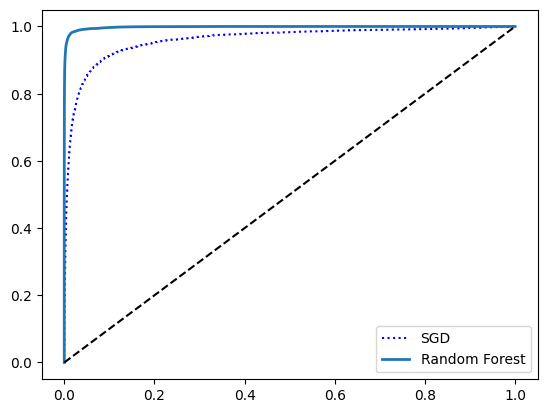

In [65]:
plt.plot(fpr, tpr, "b:", label="SGD")
plot_roc_curve(fpr_forest, tpr_forest, "Random Forest")
plt.legend(loc="lower right")
plt.show()

In [66]:
roc_auc_score(y_train_5, y_scores_forest)

0.9983296721818179

In [67]:
'''
Algorithms like SGD, Random Forest, 
naive Bayes Classifiers are capable of handling multiple classes natively. 
To classify handwritten digits into 10 classes, you can extend binary classifiers to multiclass in two main ways:

One-vs-Rest (OvR / One-vs-All):
Train one binary classifier per class. Each classifier predicts how likely a sample belongs to its class vs all other digits. For a new image, run it through all classifiers and select the class with the highest decision score.
→ requires 10 classifiers for MNIST.

One-vs-One (OvO):
Train one classifier for every pair of classes (0 vs 1, 0 vs 2, ..., 8 vs 9). For N classes, this requires N(N−1)/2 classifiers (45 for MNIST). A new image is tested by all pairwise classifiers, and the class that wins the most comparisons is chosen.
→ each classifier trains on fewer samples and is faster per classifier.

OvR is simpler and requires fewer classifiers, while OvO can be more efficient for models that train slowly on large datasets, such as SVMs.
'''


'\nAlgorithms like SGD, Random Forest, \nnaive Bayes Classifiers are capable of handling multiple classes natively. \nTo classify handwritten digits into 10 classes, you can extend binary classifiers to multiclass in two main ways:\n\nOne-vs-Rest (OvR / One-vs-All):\nTrain one binary classifier per class. Each classifier predicts how likely a sample belongs to its class vs all other digits. For a new image, run it through all classifiers and select the class with the highest decision score.\n→ requires 10 classifiers for MNIST.\n\nOne-vs-One (OvO):\nTrain one classifier for every pair of classes (0 vs 1, 0 vs 2, ..., 8 vs 9). For N classes, this requires N(N−1)/2 classifiers (45 for MNIST). A new image is tested by all pairwise classifiers, and the class that wins the most comparisons is chosen.\n→ each classifier trains on fewer samples and is faster per classifier.\n\nOvR is simpler and requires fewer classifiers, while OvO can be more efficient for models that train slowly on large 

In [68]:
from sklearn.svm import SVC

In [69]:
svm_clf = SVC()

In [70]:
svm_clf.fit(X_train, y_train)

,C,1.0
,kernel,'rbf'
,degree,3
,gamma,'scale'
,coef0,0.0
,shrinking,True
,probability,False
,tol,0.001
,cache_size,200
,class_weight,None
,verbose,False


In [71]:
svm_clf.predict([some_digit])

array([5], dtype=uint8)

In [72]:
some_digit_scores = svm_clf.decision_function([some_digit])
some_digit_scores

array([[ 1.72501977,  2.72809088,  7.2510018 ,  8.3076379 , -0.31087254,
         9.3132482 ,  1.70975103,  2.76765202,  6.23049537,  4.84771048]])

In [73]:
np.argmax(some_digit_scores)

np.int64(5)

In [74]:
svm_clf.classes_

array([0, 1, 2, 3, 4, 5, 6, 7, 8, 9], dtype=uint8)

In [75]:
svm_clf.class_weight_[5]

np.float64(1.0)

In [76]:
from sklearn.multiclass import OneVsRestClassifier

In [77]:
ovr_clf = OneVsRestClassifier(SVC())
ovr_clf.fit(X_train, y_train)
ovr_clf.predict([some_digit])

array([5], dtype=uint8)

In [78]:
len(ovr_clf.estimators_)

10

In [79]:
sgd_clf.fit(X_train, y_train)
sgd_clf.predict([some_digit])

array([3], dtype=uint8)

In [80]:
sgd_clf.decision_function([some_digit])

array([[-31893.03095419, -34419.69069632,  -9530.63950739,
          1823.73154031, -22320.14822878,  -1385.80478895,
        -26188.91070951, -16147.51323997,  -4604.35491274,
        -12050.767298  ]])

In [81]:
cross_val_score(sgd_clf, X_train, y_train, cv=3, scoring="accuracy")

array([0.87365, 0.85835, 0.8689 ])

In [82]:
from sklearn.preprocessing import StandardScaler

In [83]:
scaler = StandardScaler()

In [84]:
X_train_scaled = scaler.fit_transform(X_train.astype(np.float64))

In [85]:
cross_val_score(sgd_clf, X_train_scaled, y_train, cv=3, scoring="accuracy")

array([0.8983, 0.891 , 0.9018])

In [86]:
y_train_pred = cross_val_predict(sgd_clf, X_train_scaled, y_train, cv=3)
conf_mx = confusion_matrix(y_train, y_train_pred)
conf_mx

array([[5577,    0,   22,    5,    8,   43,   36,    6,  225,    1],
       [   0, 6400,   37,   24,    4,   44,    4,    7,  212,   10],
       [  27,   27, 5220,   92,   73,   27,   67,   36,  378,   11],
       [  22,   17,  117, 5227,    2,  203,   27,   40,  403,   73],
       [  12,   14,   41,    9, 5182,   12,   34,   27,  347,  164],
       [  27,   15,   30,  168,   53, 4444,   75,   14,  535,   60],
       [  30,   15,   42,    3,   44,   97, 5552,    3,  131,    1],
       [  21,   10,   51,   30,   49,   12,    3, 5684,  195,  210],
       [  17,   63,   48,   86,    3,  126,   25,   10, 5429,   44],
       [  25,   18,   30,   64,  118,   36,    1,  179,  371, 5107]])

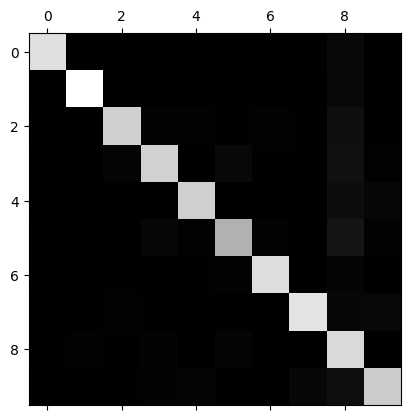

In [87]:
plt.matshow(conf_mx, cmap=plt.cm.gray)
plt.show()

In [88]:
row_sums = conf_mx.sum(axis=1, keepdims=True)
norm_conf_mx = conf_mx / row_sums

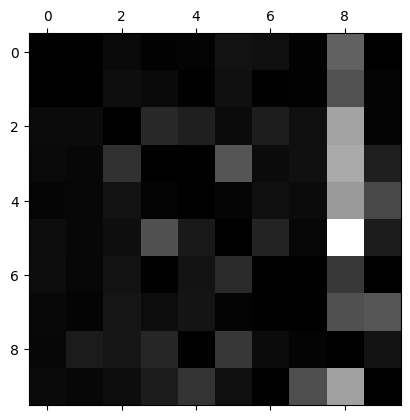

In [89]:
np.fill_diagonal(norm_conf_mx, 0)
plt.matshow(norm_conf_mx, cmap=plt.cm.gray)
plt.show()

In [90]:
cl_a, cl_b = 3,5
X_aa = X_train[(y_train == cl_a) & (y_train_pred == cl_a)]
X_ab = X_train[(y_train == cl_a) & (y_train_pred == cl_b)]
X_ba = X_train[(y_train == cl_b) & (y_train_pred == cl_a)]
X_bb = X_train[(y_train == cl_b) & (y_train_pred == cl_b)]

In [91]:
import matplotlib.pyplot as plt
import numpy as np

def plot_digits(instances, images_per_row=10, **kwargs):
    size = 28
    images = [instance.reshape(size, size) for instance in instances]
    n_rows = (len(instances) - 1) // images_per_row + 1
    row_images = []
    n_empty = n_rows * images_per_row - len(images)
    images.append(np.zeros((size, size)) * np.nan)  # pad if needed

    for row in range(n_rows):
        row_images.append(
            np.concatenate(images[row * images_per_row : (row + 1) * images_per_row], axis=1)
        )
    image = np.concatenate(row_images, axis=0)

    plt.imshow(image, cmap="binary", **kwargs)
    plt.axis("off")


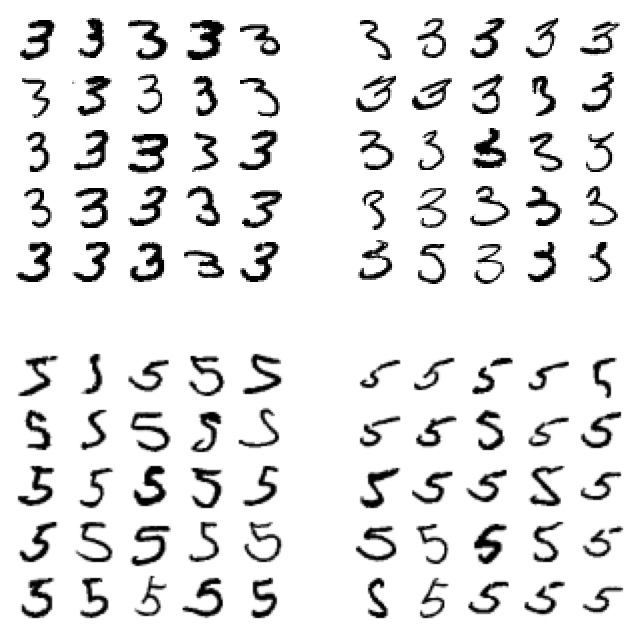

In [92]:
plt.figure(figsize=(8,8))
plt.subplot(221); plot_digits(X_aa[:25], images_per_row=5)
plt.subplot(222); plot_digits(X_ab[:25], images_per_row=5)
plt.subplot(223); plot_digits(X_ba[:25], images_per_row=5)
plt.subplot(224); plot_digits(X_bb[:25], images_per_row=5)
plt.show()

In [93]:
from sklearn.neighbors import KNeighborsClassifier

In [94]:
y_train_large = (y_train >= 7)

In [95]:
y_train_odd = (y_train % 2 ==1 )

In [96]:
y_multilabel = np.c_[y_train_large, y_train_odd]

In [97]:
knn_clf = KNeighborsClassifier()
knn_clf.fit(X_train, y_multilabel)

,n_neighbors,5
,weights,'uniform'
,algorithm,'auto'
,leaf_size,30
,p,2
,metric,'minkowski'
,metric_params,None
,n_jobs,None


In [100]:
knn_clf.predict([some_digit])

array([[False,  True]])

In [101]:
y_train_knn_pred = cross_val_predict(knn_clf, X_train, y_multilabel, cv=3)
f1_score(y_multilabel, y_train_knn_pred, average="macro")

0.9764102655606048

In [107]:
X_train = np.array(X_train)
X_test  = np.array(X_test)

X_train_clean = X_train.copy()
X_test_clean  = X_test.copy()

X_train_mod = X_train_clean + np.random.randint(0, 100, X_train_clean.shape)
X_test_mod  = X_test_clean  + np.random.randint(0, 100, X_test_clean.shape)

X_train_mod = np.clip(X_train_mod, 0, 255)
X_test_mod  = np.clip(X_test_mod, 0, 255)

y_train_mod = X_train_clean
y_test_mod  = X_test_clean

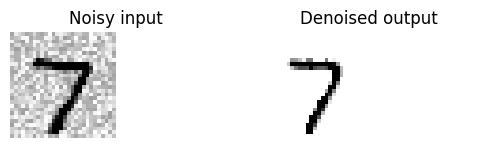

In [111]:
some_index = 0 
clean_digit = knn_clf.predict([X_test_mod[some_index]])
plt.figure(figsize=(6, 3))
plt.subplot(121)
plot_digits([X_test_mod[some_index]])
plt.title("Noisy input")

plt.subplot(122)
plot_digits(clean_digit)
plt.title("Denoised output")

plt.show()